# 05 · Representation-Free Pivots — The Clock

Every notebook so far first turned numbers into bits. But *why base 2?* The digits
of a number are an arbitrary costume. This notebook throws the costume away and
describes a series only by **where its salient points fall** — its **pivots** —
along two axes: **time** and **value**. No binarisation, no units; the description
does not change if you multiply every price by 1000.

This is the most agnostic view, and it hands us the deepest result of the
programme: the information lives in a **clock** — in *when* things happen, not in
*how big* they are.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. What is a pivot?

Walk along the price. Remember the highest point reached. As soon as the price
falls from that high by a chosen fraction $\theta$ (say 5%), we **confirm a pivot**
at that high: the trend has turned. Then we track the new low, and so on. A pivot is
simply a **confirmed turning point**. Between two pivots the price is a single
sweep, which we call a **leg**.

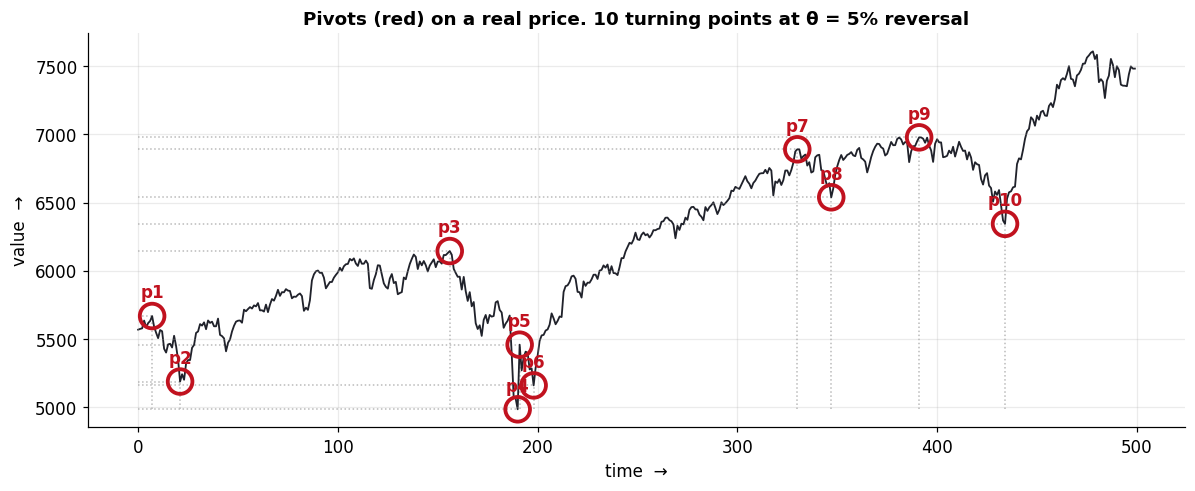

Each pivot projects onto TWO axes: a time coordinate and a value coordinate.


In [2]:
from controls import load_long_sequences
from pivots import directional_change_pivots, legs

series = load_long_sequences()
window = series["SP500"][-500:]                       # last 500 days
theta = 0.05                                          # a pivot = a 5% reversal
pv = directional_change_pivots(window, theta)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(window, color=INK, lw=1.2, zorder=1)
for j, p in enumerate(pv):
    ax.scatter(p.index, p.value, s=260, facecolor="none", edgecolor=HL, lw=2.5, zorder=3)
    ax.annotate(f"p{j+1}", (p.index, p.value), color=HL, fontweight="bold",
                xytext=(0, 12), textcoords="offset points", ha="center")
    ax.plot([p.index, p.index], [min(window), p.value], ls=":", color="#bbb", lw=1, zorder=0)  # onto TIME axis
    ax.plot([0, p.index], [p.value, p.value], ls=":", color="#bbb", lw=1, zorder=0)            # onto VALUE axis
ax.set_xlabel("time  →"); ax.set_ylabel("value  →")
ax.set_title(f"Pivots (red) on a real price. {len(pv)} turning points at θ = {theta:.0%} reversal")
plt.tight_layout(); plt.show()
print("Each pivot projects onto TWO axes: a time coordinate and a value coordinate.")

## 2. The representation-free encoding: legs (Δt, Δv)

The whole series between its pivots is a list of pairs: **Δt** (how long the leg
lasted) and **Δv** (how far, and which way, it moved). No digits, no base — just the
geometry of the turning points. This is what we analyse.

first few legs (Δt in days, Δv in price):
   waited  14 days, moved   -480.9
   waited 135 days, moved   +957.8
   waited  34 days, moved  -1161.4
   waited   1 days, moved   +474.1
   waited   7 days, moved   -298.7
   waited 132 days, moved  +1732.7


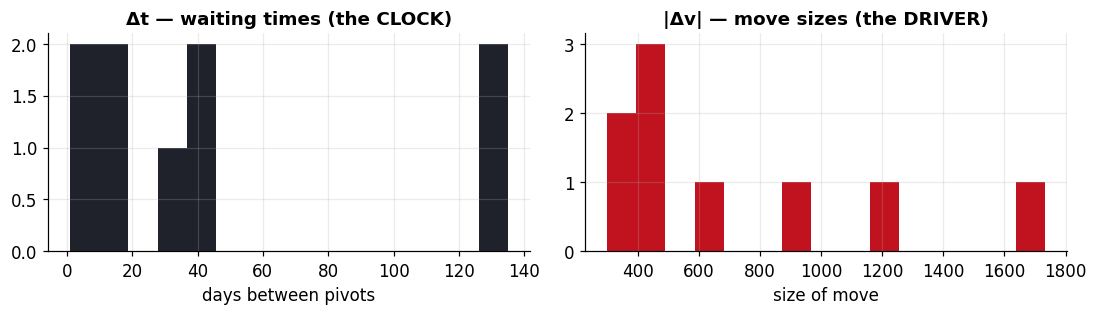

In [3]:
lg = legs(pv)
dt = [a for a, _ in lg]; dv = [b for _, b in lg]
print("first few legs (Δt in days, Δv in price):")
for a, b in lg[:6]:
    print(f"   waited {a:3d} days, moved {b:+8.1f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(dt, bins=15, color=INK); axes[0].set_title("Δt — waiting times (the CLOCK)")
axes[0].set_xlabel("days between pivots")
axes[1].hist([abs(x) for x in dv], bins=15, color=HL); axes[1].set_title("|Δv| — move sizes (the DRIVER)")
axes[1].set_xlabel("size of move")
plt.tight_layout(); plt.show()

## 3. Benford's law — the gaps are naturally scale-free

Benford's law says the leading digit of many natural quantities is 1 far more often
than 9. It is a fingerprint of **scale-invariance**. Our pivot gaps, being
differences under a *relative* threshold, should obey it — and they obey it far
better than the raw prices do. This confirms that describing the series by
occurrences, not digits, captures the natural, unit-free structure.

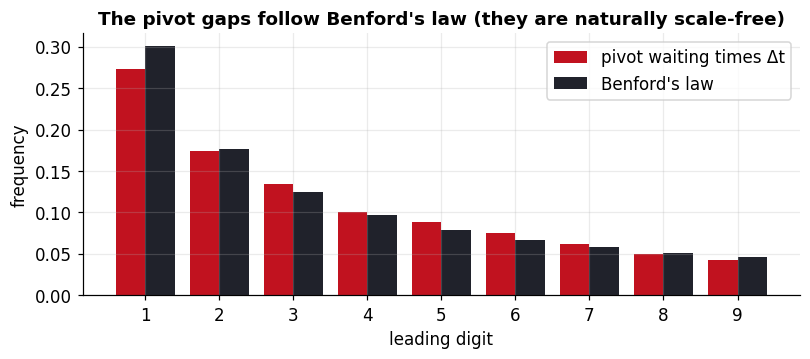

distance from Benford — raw prices 0.207  vs  pivot gaps 0.041  (smaller = closer)


In [4]:
from occurrence_geometry import benford_distance, BENFORD

# pool waiting times over all long series at a fine threshold
all_dt = []
for s in series.values():
    all_dt += [a for a, _ in legs(directional_change_pivots(s, 0.02))]
hist = benford_distance(all_dt)["hist"]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.arange(1, 10)
ax.bar(x-0.2, hist, 0.4, color=HL, label="pivot waiting times Δt")
ax.bar(x+0.2, BENFORD, 0.4, color=INK, label="Benford's law")
ax.set_xticks(x); ax.set_xlabel("leading digit"); ax.set_ylabel("frequency"); ax.legend()
ax.set_title("The pivot gaps follow Benford's law (they are naturally scale-free)")
plt.tight_layout(); plt.show()
raw_tv = np.mean([benford_distance(s)["tv"] for s in series.values()])
dt_tv  = np.mean([benford_distance([a for a,_ in legs(directional_change_pivots(s,0.02))])["tv"] for s in series.values()])
print(f"distance from Benford — raw prices {raw_tv:.3f}  vs  pivot gaps {dt_tv:.3f}  (smaller = closer)")

## 4. The headline: the information is in the *clock*, not the *driver*

Re-index time so that each leg is one tick ("event time"). Now ask where the memory
is. The **driver** (move sizes) and the **clock** (waiting times): which one repeats
itself? We compare each to a **return-shuffle** null that keeps the fat-tailed size
distribution but destroys time order.

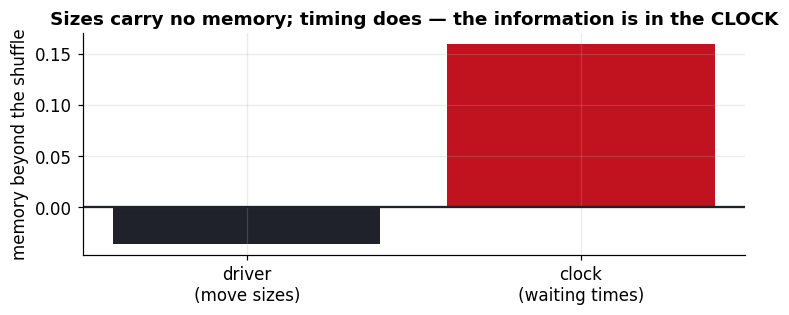

driver excess -0.036 (4/12 positive)
clock  excess +0.160 (12/12 positive)


In [5]:
from occurrence_geometry import intrinsic_time_memory
from controls import return_shuffle
import statistics, random
rng = random.Random(0)

drv_ex, clk_ex = [], []
for s in series.values():
    real = intrinsic_time_memory(s, 0.03)
    nd, nc = [], []
    for _ in range(15):
        r = intrinsic_time_memory(return_shuffle(s, rng), 0.03)
        nd.append(r["driver_ac1"]); nc.append(r["clock_ac1"])
    drv_ex.append(real["driver_ac1"] - statistics.mean(nd))
    clk_ex.append(real["clock_ac1"] - statistics.mean(nc))

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["driver\n(move sizes)", "clock\n(waiting times)"],
       [np.mean(drv_ex), np.mean(clk_ex)], color=[INK, HL])
ax.axhline(0, color=INK); ax.set_ylabel("memory beyond the shuffle")
ax.set_title("Sizes carry no memory; timing does — the information is in the CLOCK")
plt.tight_layout(); plt.show()
print(f"driver excess {np.mean(drv_ex):+.3f} ({sum(1 for x in drv_ex if x>0)}/{len(drv_ex)} positive)")
print(f"clock  excess {np.mean(clk_ex):+.3f} ({sum(1 for x in clk_ex if x>0)}/{len(clk_ex)} positive)")

## Takeaways

* A **pivot** is a confirmed turning point; the series becomes a list of legs
  **(Δt, Δv)** — a description free of any number representation and invariant to
  rescaling.
* The gaps obey **Benford's law** — the encoding is naturally scale-free.
* The deep result: in event time, the **move sizes carry no memory** beyond their
  fat tails, but the **timing of pivots clusters**. The information is a **clock** —
  *when*, not *how big*.

**Next (06):** we show this clock is a genuine **fractal**, self-similar across
scales, and largely **shared** across different instruments.